# EDA — NSL-KDD Dataset
Exploratory Data Analysis on the KDD Train/Test dataset before model building.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)

## 1. Load & Label Data

In [2]:
cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'KDDTrain+.txt'), names=cols)
test  = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'KDDTest+.txt'),  names=cols)

train.drop('difficulty', axis=1, inplace=True)
test.drop('difficulty',  axis=1, inplace=True)

label_map = {
    'normal': 'Normal',
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'xlock':'R2L','xsnoop':'R2L','worm':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'httptunnel':'U2R','ps':'U2R','sqlattack':'U2R','xterm':'U2R'
}

train['label'] = train['label'].map(label_map)
test['label']  = test['label'].map(label_map)

print('Train:', train.shape, '  Test:', test.shape)
train.head(3)

Train: (125973, 42)   Test: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,DoS


## 2. Missing Values

In [3]:
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values — clean dataset!')

No missing values — clean dataset!


## 3. Class Distribution

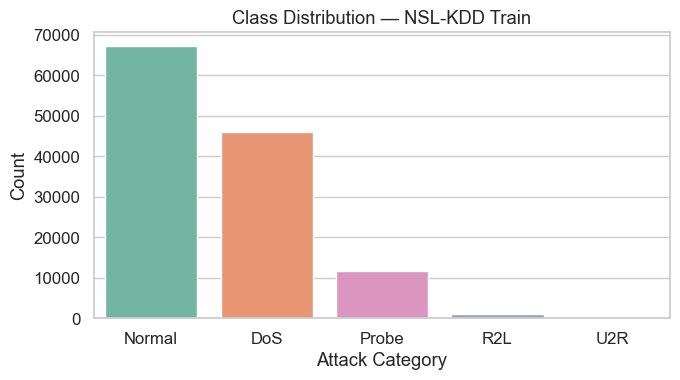

        Count  Percent
label                 
Normal  67343    53.46
DoS     45927    36.46
Probe   11656     9.25
R2L       995     0.79
U2R        52     0.04


In [4]:
order = train['label'].value_counts().index

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=train, x='label', order=order, hue='label', palette='Set2', legend=False, ax=ax)
ax.set_title('Class Distribution — NSL-KDD Train')
ax.set_xlabel('Attack Category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

dist = train['label'].value_counts()
pct  = dist / dist.sum() * 100
print(pd.DataFrame({'Count': dist, 'Percent': pct.round(2)}))

## 4. Categorical Features

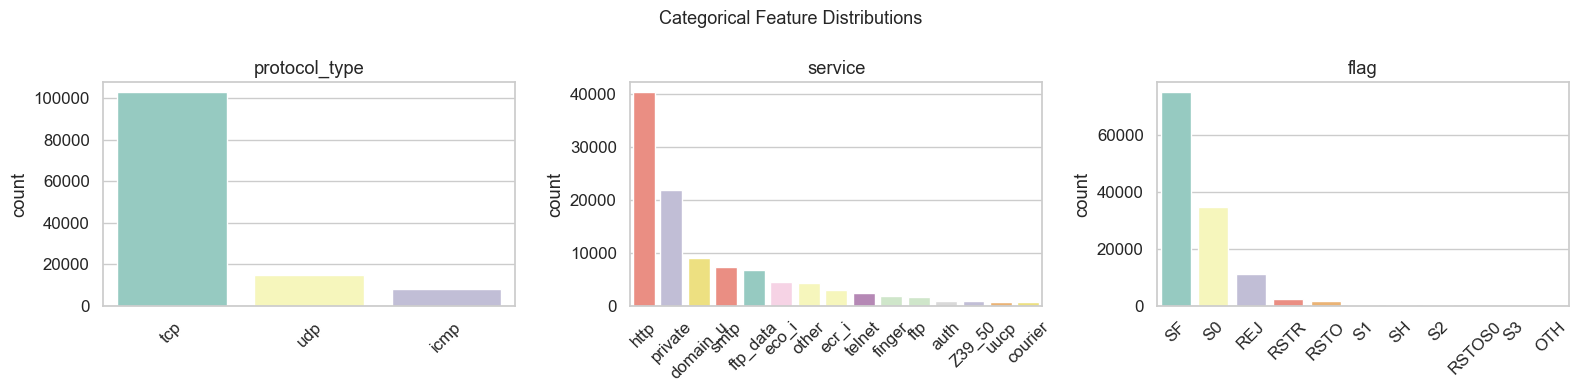

In [5]:
cat_cols = ['protocol_type', 'service', 'flag']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    order = train[col].value_counts().index[:15]
    sns.countplot(data=train, x=col, order=order, hue=col, palette='Set3', legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Numeric Feature Distributions

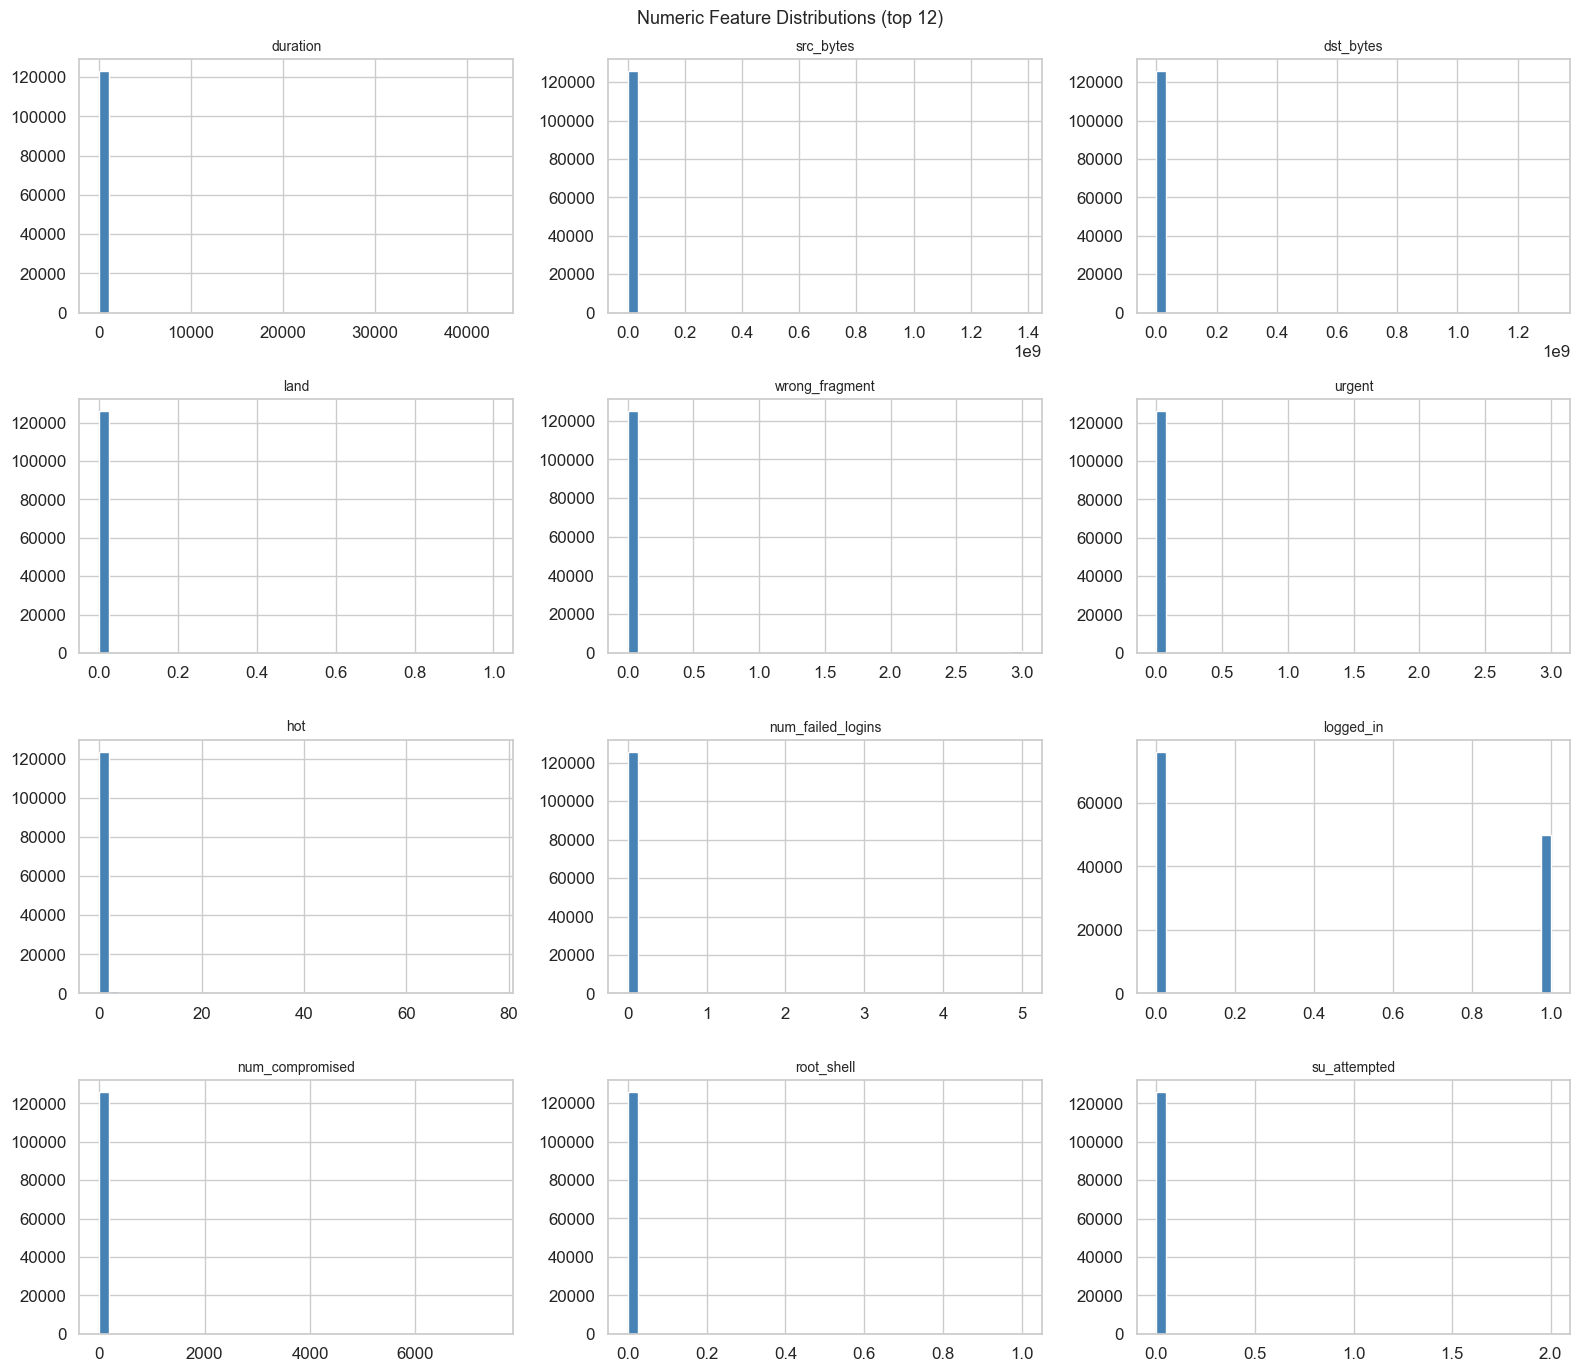

In [6]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), num_cols[:12]):
    train[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Numeric Feature Distributions (top 12)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

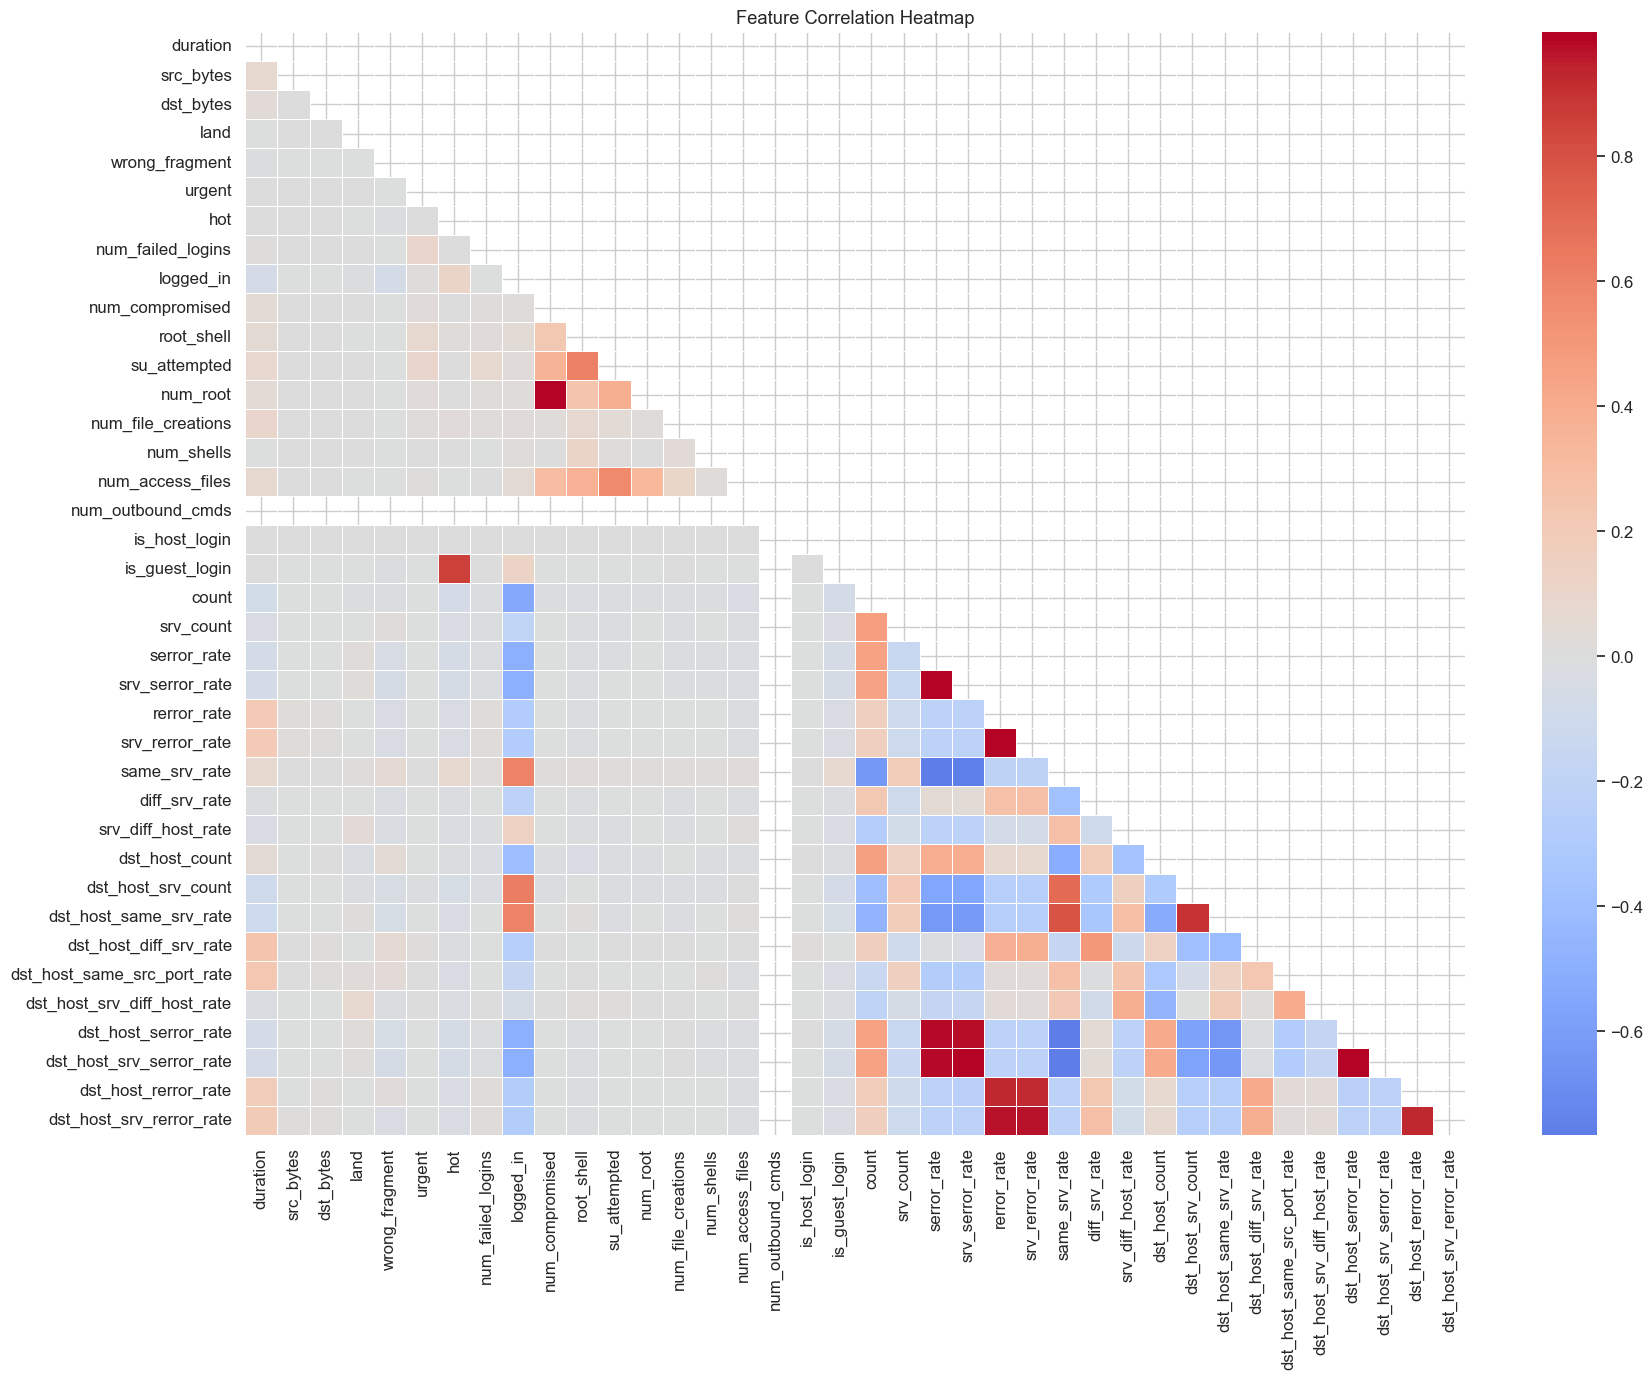

In [7]:
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.4, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Key Features by Attack Category

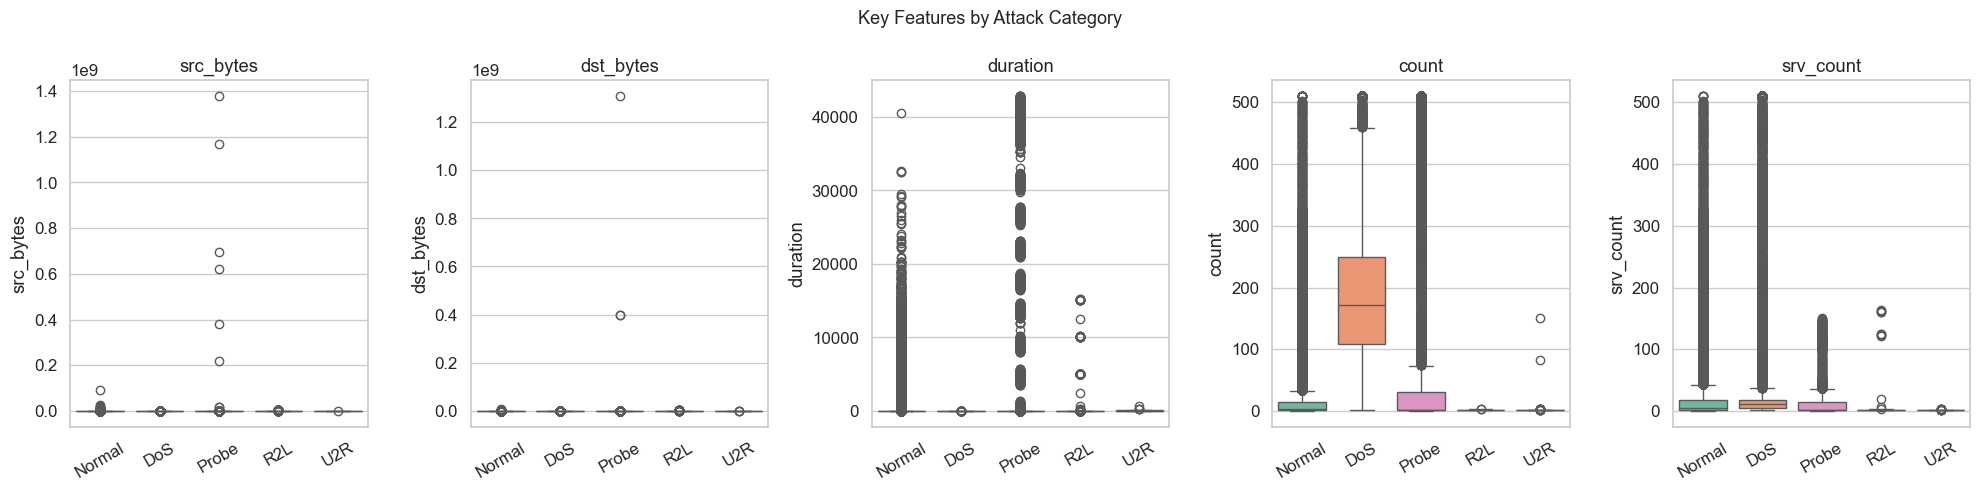

In [8]:
key_features = ['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']
order = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

fig, axes = plt.subplots(1, len(key_features), figsize=(20, 5))
for ax, feat in zip(axes, key_features):
    sns.boxplot(data=train, x='label', y=feat, order=order,
                hue='label', palette='Set2', legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Key Features by Attack Category', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Protocol vs Attack Category

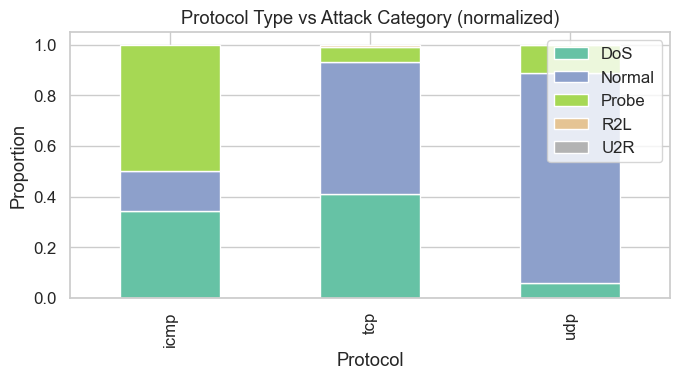

In [9]:
ct = pd.crosstab(train['protocol_type'], train['label'])
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', stacked=True, colormap='Set2', figsize=(7, 4))
plt.title('Protocol Type vs Attack Category (normalized)')
plt.xlabel('Protocol')
plt.ylabel('Proportion')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. Summary Stats per Class

In [10]:
train.groupby('label')[['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']].mean().round(2)

,src_bytes,dst_bytes,duration,count,srv_count
label,,,,,
DoS,1176.32,169.20,0.01,178.09,32.66
Normal,13133.28,4329.69,168.59,22.52,27.69
Probe,385679.84,181074.91,2074.86,77.05,10.94
R2L,307727.30,81822.03,633.42,1.30,2.46
U2R,906.23,5141.96,80.94,5.81,1.27
